In [1]:
!pip install -q kaggle

In [2]:
import os
from google.colab import userdata

os.environ["KAGGLE_API_TOKEN"] = userdata.get("KAGGLE_API_TOKEN")

print("Kaggle authentication configured successfully.")

Kaggle authentication configured successfully.


In [3]:
!kaggle datasets download -d lorenzozoppelletto/financial-risk-for-loan-approval

Dataset URL: https://www.kaggle.com/datasets/lorenzozoppelletto/financial-risk-for-loan-approval
License(s): CC0-1.0
100% 2.15M/2.15M [00:00<00:00, 157MB/s]



In [4]:
!unzip -o financial-risk-for-loan-approval.zip -d credit_data

Archive:  financial-risk-for-loan-approval.zip
  inflating: credit_data/CSV Generation.py  
  inflating: credit_data/Loan.csv    


In [5]:
import pandas as pd

df = pd.read_csv("credit_data/Loan.csv")

print("Dataset shape:", df.shape)

Dataset shape: (20000, 36)


In [6]:
df.head()

,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,2018-01-01,45,39948,617,Employed,Master,22,13152,48,Married,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,2018-01-02,38,39709,628,Employed,Associate,15,26045,48,Single,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,2018-01-03,47,40724,570,Employed,Bachelor,26,17627,36,Married,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,2018-01-04,58,69084,545,Employed,High School,34,37898,96,Single,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,2018-01-05,37,103264,594,Employed,Associate,17,9184,36,Married,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


In [7]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

Number of rows: 20000
Number of columns: 36

Column names:
['ApplicationDate', 'Age', 'AnnualIncome', 'CreditScore', 'EmploymentStatus', 'EducationLevel', 'Experience', 'LoanAmount', 'LoanDuration', 'MaritalStatus', 'NumberOfDependents', 'HomeOwnershipStatus', 'MonthlyDebtPayments', 'CreditCardUtilizationRate', 'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'BankruptcyHistory', 'LoanPurpose', 'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'LoanApproved', 'RiskScore']


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             20000 non-null  object 
 1   Age                         20000 non-null  int64  
 2   AnnualIncome                20000 non-null  int64  
 3   CreditScore                 20000 non-null  int64  
 4   EmploymentStatus            20000 non-null  object 
 5   EducationLevel              20000 non-null  object 
 6   Experience                  20000 non-null  int64  
 7   LoanAmount                  20000 non-null  int64  
 8   LoanDuration                20000 non-null  int64  
 9   MaritalStatus               20000 non-null  object 
 10  NumberOfDependents          20000 non-null  int64  
 11  HomeOwnershipStatus         20000 non-null  object 
 12  MonthlyDebtPayments         20000 non-null  int64  
 13  CreditCardUtilizationRate   200

In [9]:
print("Loan Approval Distribution:")
print(df["LoanApproved"].value_counts())

print("\nPercentage:")
print(df["LoanApproved"].value_counts(normalize=True) * 100)

Loan Approval Distribution:
LoanApproved
0    15220
1     4780
Name: count, dtype: int64

Percentage:
LoanApproved
0    76.1
1    23.9
Name: proportion, dtype: float64


In [10]:
features = [
    'Age',
    'AnnualIncome',
    'CreditScore',
    'EmploymentStatus',
    'EducationLevel',
    'Experience',
    'LoanAmount',
    'LoanDuration',
    'MaritalStatus',
    'NumberOfDependents',
    'HomeOwnershipStatus',
    'MonthlyDebtPayments',
    'CreditCardUtilizationRate',
    'NumberOfOpenCreditLines',
    'NumberOfCreditInquiries',
    'DebtToIncomeRatio',
    'BankruptcyHistory',
    'LoanPurpose',
    'PreviousLoanDefaults',
    'PaymentHistory',
    'LengthOfCreditHistory',
    'SavingsAccountBalance',
    'CheckingAccountBalance',
    'TotalAssets',
    'TotalLiabilities',
    'MonthlyIncome',
    'UtilityBillsPaymentHistory',
    'JobTenure',
    'NetWorth'
]

target = 'LoanApproved'

X = df[features]
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (20000, 29)
y shape: (20000,)


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training data: (16000, 29)
Testing data: (4000, 29)

Training target distribution:
LoanApproved
0    12176
1     3824
Name: count, dtype: int64

Testing target distribution:
LoanApproved
0    3044
1     956
Name: count, dtype: int64


In [12]:
categorical_features = X.select_dtypes(
    include=['object']
).columns.tolist()

numerical_features = X.select_dtypes(
    exclude=['object']
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumber of numerical features:", len(numerical_features))
print("Number of categorical features:", len(categorical_features))

Categorical features:
['EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose']

Number of numerical features: 24
Number of categorical features: 5


In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numerical_features
        ),
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        )
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [14]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

logistic_model.fit(X_train, y_train)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [15]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

y_pred_lr = logistic_model.predict(X_test)
y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

print("Logistic Regression Results")
print("=" * 40)

print(f"Accuracy : {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_lr):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Results
Accuracy : 0.9225
Precision: 0.8581
Recall   : 0.8096
F1 Score : 0.8332
ROC-AUC  : 0.9734

Confusion Matrix:
[[2916  128]
 [ 182  774]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      3044
           1       0.86      0.81      0.83       956

    accuracy                           0.92      4000
   macro avg       0.90      0.88      0.89      4000
weighted avg       0.92      0.92      0.92      4000



In [16]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(
            max_depth=8,
            random_state=42
        ))
    ]
)

decision_tree_model.fit(X_train, y_train)

print("Decision Tree trained successfully.")

Decision Tree trained successfully.


In [17]:
y_pred_dt = decision_tree_model.predict(X_test)
y_prob_dt = decision_tree_model.predict_proba(X_test)[:, 1]

print("Decision Tree Results")
print("=" * 40)

print(f"Accuracy : {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_dt):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_dt):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_dt):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_dt):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Results
Accuracy : 0.8790
Precision: 0.7744
Recall   : 0.6967
F1 Score : 0.7335
ROC-AUC  : 0.9107

Confusion Matrix:
[[2850  194]
 [ 290  666]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.94      0.92      3044
           1       0.77      0.70      0.73       956

    accuracy                           0.88      4000
   macro avg       0.84      0.82      0.83      4000
weighted avg       0.88      0.88      0.88      4000



In [18]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(
            n_estimators=200,
            max_depth=12,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

random_forest_model.fit(X_train, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [19]:
y_pred_rf = random_forest_model.predict(X_test)
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

print("Random Forest Results")
print("=" * 40)

print(f"Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_rf):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Results
Accuracy : 0.9055
Precision: 0.8668
Recall   : 0.7144
F1 Score : 0.7833
ROC-AUC  : 0.9582

Confusion Matrix:
[[2939  105]
 [ 273  683]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      3044
           1       0.87      0.71      0.78       956

    accuracy                           0.91      4000
   macro avg       0.89      0.84      0.86      4000
weighted avg       0.90      0.91      0.90      4000



In [20]:
print('random_forest_model' in globals())
print('logistic_model' in globals())
print('decision_tree_model' in globals())

True
True
True


In [21]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_dt),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.9225,0.858093,0.809623,0.833154,0.973430
1,Decision Tree,0.8790,0.774419,0.696653,0.733480,0.910685
2,Random Forest,0.9055,0.866751,0.714435,0.783257,0.958226


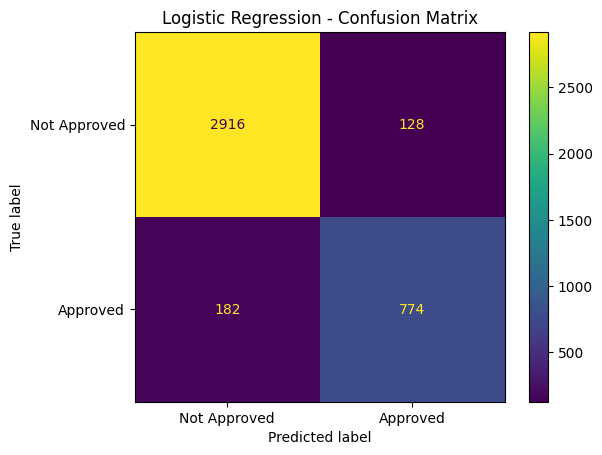

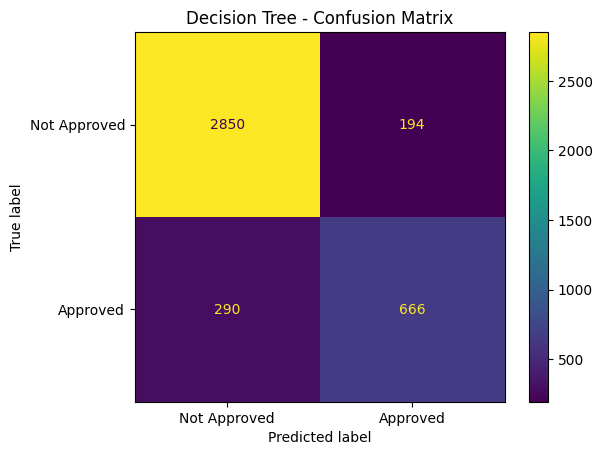

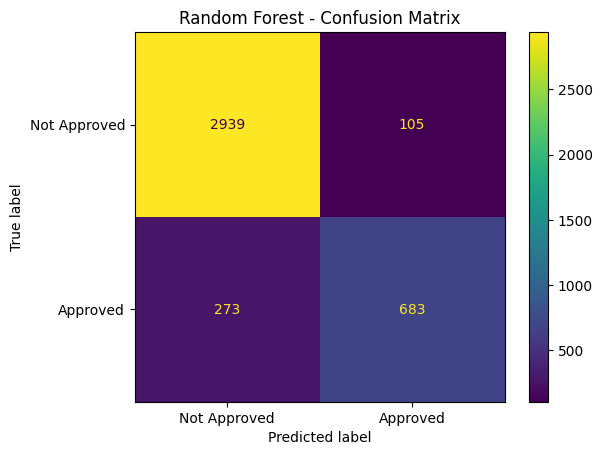

In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model
}

for name, model in models.items():

    y_pred = model.predict(X_test)

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        display_labels=["Not Approved", "Approved"]
    )

    plt.title(f"{name} - Confusion Matrix")
    plt.show()

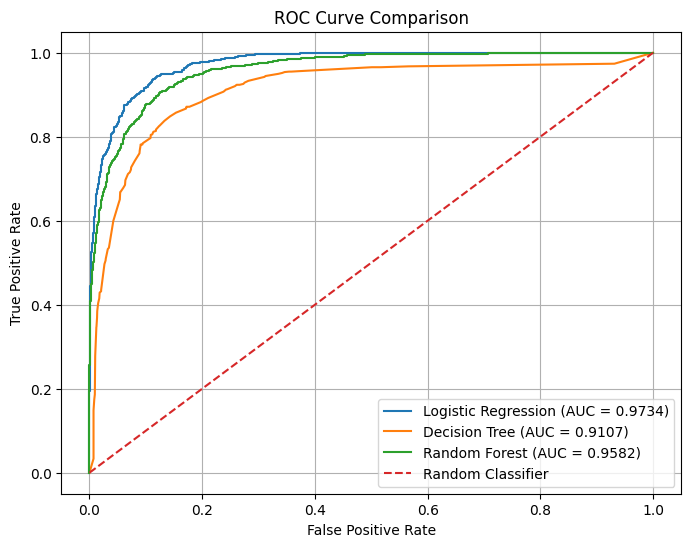

In [23]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8, 6))

model_probabilities = {
    "Logistic Regression": y_prob_lr,
    "Decision Tree": y_prob_dt,
    "Random Forest": y_prob_rf
}

for name, y_prob in model_probabilities.items():

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {roc_auc:.4f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)

plt.show()

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# Get the fitted preprocessing step
preprocessor_fitted = logistic_model.named_steps["preprocessor"]

# Get feature names after preprocessing
feature_names = preprocessor_fitted.get_feature_names_out()

# Get Logistic Regression coefficients
coefficients = logistic_model.named_steps["classifier"].coef_[0]

# Create a DataFrame
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Calculate absolute coefficient magnitude
feature_importance["Absolute_Coefficient"] = (
    feature_importance["Coefficient"].abs()
)

# Sort by importance
feature_importance = feature_importance.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

# Display top 15
print("Top 15 Most Influential Features:")
display(feature_importance.head(15))

Top 15 Most Influential Features:


,Feature,Coefficient,Absolute_Coefficient
20,num__MonthlyIncome,3.878070,3.878070
4,num__LoanAmount,-2.877234,2.877234
30,cat__EducationLevel_High School,-1.578822,1.578822
26,cat__EmploymentStatus_Unemployed,-1.535382,1.535382
23,num__NetWorth,1.056230,1.056230
29,cat__EducationLevel_Doctorate,1.004612,1.004612
27,cat__EducationLevel_Associate,-0.936772,0.936772
15,num__LengthOfCreditHistory,0.877766,0.877766
5,num__LoanDuration,-0.848257,0.848257
12,num__BankruptcyHistory,-0.832151,0.832151


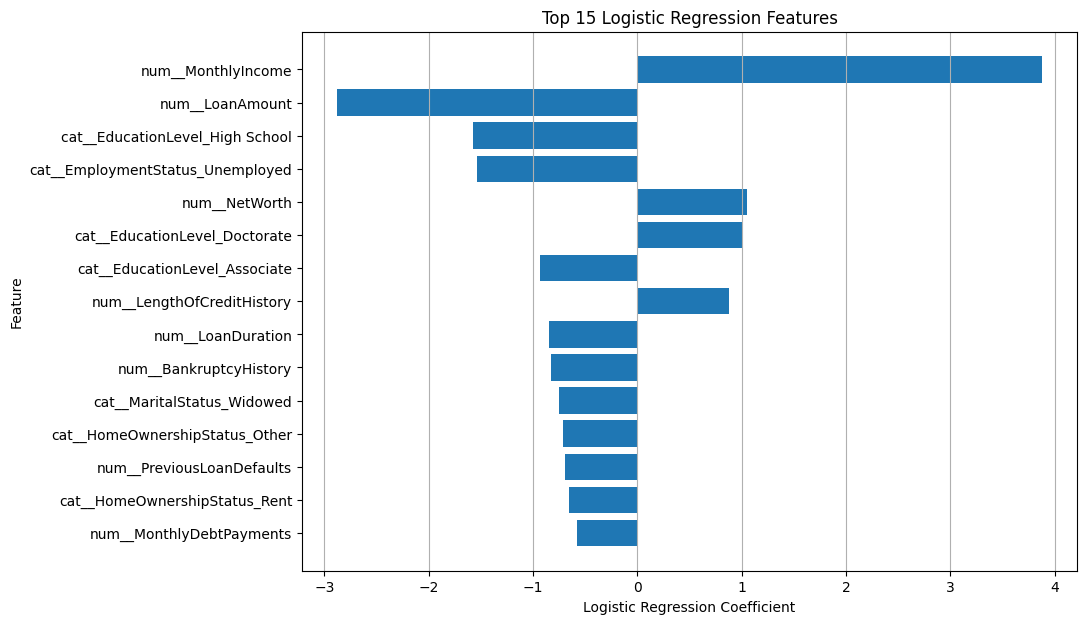

In [25]:
top_features = feature_importance.head(15).sort_values(
    "Absolute_Coefficient"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Top 15 Logistic Regression Features")
plt.grid(axis="x")

plt.show()

In [26]:
import joblib

joblib.dump(
    logistic_model,
    "credit_scoring_logistic_regression.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [27]:
import os

print(os.path.getsize("credit_scoring_logistic_regression.pkl"), "bytes")

6785 bytes


In [28]:
loaded_model = joblib.load(
    "credit_scoring_logistic_regression.pkl"
)

test_predictions = loaded_model.predict(X_test)

print("Loaded model tested successfully!")
print("Predictions generated:", len(test_predictions))

Loaded model tested successfully!
Predictions generated: 4000


In [29]:
# Select one applicant from the test set
sample_applicant = X_test.iloc[[0]]

# Get the actual result
actual_result = y_test.iloc[0]

# Make prediction
prediction = loaded_model.predict(sample_applicant)[0]

# Get approval probability
probability = loaded_model.predict_proba(sample_applicant)[0][1]

print("Sample Applicant Prediction")
print("=" * 40)

print("Actual result:",
      "Approved" if actual_result == 1 else "Not Approved")

print("Predicted result:",
      "Approved" if prediction == 1 else "Not Approved")

print(f"Approval probability: {probability:.2%}")

Sample Applicant Prediction
Actual result: Not Approved
Predicted result: Not Approved
Approval probability: 0.00%


In [30]:
sample_applicant.T

,10665
Age,39
AnnualIncome,22074
CreditScore,609
EmploymentStatus,Employed
EducationLevel,Associate
Experience,17
LoanAmount,60015
LoanDuration,48
MaritalStatus,Married
NumberOfDependents,0


In [31]:
results.to_csv(
    "model_comparison.csv",
    index=False
)

print("Model comparison saved successfully!")

Model comparison saved successfully!


In [32]:
sample_applicant = X_test.iloc[[0]]

actual_result = y_test.iloc[0]

prediction = loaded_model.predict(sample_applicant)[0]

probability = loaded_model.predict_proba(sample_applicant)[0][1]

print("Sample Applicant Prediction")
print("=" * 40)

print(
    "Actual result:",
    "Approved" if actual_result == 1 else "Not Approved"
)

print(
    "Predicted result:",
    "Approved" if prediction == 1 else "Not Approved"
)

print(f"Approval probability: {probability:.2%}")

Sample Applicant Prediction
Actual result: Not Approved
Predicted result: Not Approved
Approval probability: 0.00%
